# 07 — Actual World Cup 2026 Model Validation

This notebook compares World Cup 2026 predictions from several goal regression models against completed real matches.

## Project Setup

The notebook loads the feature-engineered project data, trains comparable goal regression models, predicts World Cup 2026 fixtures, and validates completed matches against actual results.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas.api.types import is_numeric_dtype
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

PROJECT_DIR = Path("..").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"

VALIDATION_DIR = OUTPUT_DIR / "actual_worldcup2026_validation"
TABLES_DIR = VALIDATION_DIR / "tables"
FIGURES_DIR = VALIDATION_DIR / "figures"

for directory in [TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Processed data folder:", PROCESSED_DIR)
print("Validation output folder:", VALIDATION_DIR)
print("XGBoost available:", XGBOOST_AVAILABLE)
print("LightGBM available:", LIGHTGBM_AVAILABLE)


Project folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026
Processed data folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\data\processed
Validation output folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\actual_worldcup2026_validation
XGBoost available: True
LightGBM available: True


## Load Training Dataset and World Cup Fixtures

The training dataset is used to train goal regression models. The World Cup fixture feature table is used for tournament prediction.

In [2]:
model_dataset = pd.read_csv(PROCESSED_DIR / "model_dataset.csv")
fixture_features = pd.read_csv(PROCESSED_DIR / "wc2026_fixture_features.csv")
fixtures = pd.read_csv(PROCESSED_DIR / "wc2026_fixtures.csv")

model_dataset["date"] = pd.to_datetime(model_dataset["date"], errors="coerce")
fixture_features["date"] = pd.to_datetime(fixture_features["date"], errors="coerce")
fixtures["date"] = pd.to_datetime(fixtures["date"], errors="coerce")

# Normalize match number column names across notebooks.
def normalize_match_number_column(df, df_name):
    if "match_number" in df.columns:
        return df
    if "match_no" in df.columns:
        df = df.rename(columns={"match_no": "match_number"})
        print(f"{df_name}: renamed match_no to match_number")
        return df
    if "Match Number" in df.columns:
        df = df.rename(columns={"Match Number": "match_number"})
        print(f"{df_name}: renamed Match Number to match_number")
        return df
    raise KeyError(
        f"{df_name} does not contain a match number column. "
        f"Available columns: {list(df.columns)}"
    )

fixture_features = normalize_match_number_column(fixture_features, "fixture_features")
fixtures = normalize_match_number_column(fixtures, "fixtures")

# Make sure match_number has a consistent numeric type.
fixture_features["match_number"] = pd.to_numeric(fixture_features["match_number"], errors="coerce").astype("Int64")
fixtures["match_number"] = pd.to_numeric(fixtures["match_number"], errors="coerce").astype("Int64")

# Keep only group-stage fixtures.
fixture_features = fixture_features[
    fixture_features["group"].notna()
    & fixture_features["group"].astype(str).str.startswith("Group ")
].copy()

fixtures = fixtures[
    fixtures["group"].notna()
    & fixtures["group"].astype(str).str.startswith("Group ")
].copy()

print("Training dataset:", model_dataset.shape)
print("Group-stage fixture features:", fixture_features.shape)
print("Fixture feature columns:", list(fixture_features.columns))
display(fixture_features.head())


fixture_features: renamed match_no to match_number
fixtures: renamed match_no to match_number
Training dataset: (8000, 45)
Group-stage fixture features: (72, 48)
Fixture feature columns: ['team_a', 'team_b', 'date', 'tournament', 'neutral', 'team_a_matches_last5', 'team_b_matches_last5', 'team_a_win_rate_last5', 'team_b_win_rate_last5', 'team_a_draw_rate_last5', 'team_b_draw_rate_last5', 'team_a_loss_rate_last5', 'team_b_loss_rate_last5', 'team_a_points_per_match_last5', 'team_b_points_per_match_last5', 'team_a_matches_last10', 'team_b_matches_last10', 'team_a_win_rate_last10', 'team_b_win_rate_last10', 'team_a_draw_rate_last10', 'team_b_draw_rate_last10', 'team_a_loss_rate_last10', 'team_b_loss_rate_last10', 'team_a_avg_goals_scored_last10', 'team_b_avg_goals_scored_last10', 'team_a_avg_goals_conceded_last10', 'team_b_avg_goals_conceded_last10', 'team_a_avg_goal_diff_last10', 'team_b_avg_goal_diff_last10', 'team_a_points_per_match_last10', 'team_b_points_per_match_last10', 'win_rate_d

,team_a,team_b,date,tournament,neutral,team_a_matches_last5,team_b_matches_last5,team_a_win_rate_last5,team_b_win_rate_last5,team_a_draw_rate_last5,...,team_b_h2h_win_rate,h2h_draw_rate,team_a_h2h_avg_goals,team_b_h2h_avg_goals,match_number,stage,group,venue,city,country
0,Mexico,South Africa,2026-06-11,FIFA World Cup 2026,True,5,5,0.6,0.2,0.4,...,0.333333,0.333333,2.000,1.666667,<NA>,NaN,Group A,Mexico City Stadium,NaN,NaN
1,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,2026-06-11,FIFA World Cup 2026,True,5,0,0.6,0.0,0.0,...,0.000000,0.000000,0.000,0.000000,<NA>,NaN,Group A,Estadio Guadalajara,NaN,NaN
2,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,2026-06-12,FIFA World Cup 2026,True,5,0,0.4,0.0,0.6,...,0.000000,0.000000,0.000,0.000000,<NA>,NaN,Group B,Toronto Stadium,NaN,NaN
3,USA,Paraguay,2026-06-12,FIFA World Cup 2026,True,5,5,0.4,0.6,0.0,...,0.250000,0.250000,1.125,0.875000,<NA>,NaN,Group D,Los Angeles Stadium,NaN,NaN
4,Haiti,Scotland,2026-06-13,FIFA World Cup 2026,True,5,5,0.4,0.6,0.2,...,0.000000,0.000000,0.000,0.000000,<NA>,NaN,Group C,Boston Stadium,NaN,NaN


## Actual Completed World Cup 2026 Results

This table contains completed group-stage matches used for validation. It can be extended later as more matches are played.

In [3]:
actual_results = pd.DataFrame([
    {"match_number": 1, "team_a": "Mexico", "team_b": "South Africa", "actual_team_a_goals": 2, "actual_team_b_goals": 0},
    {"match_number": 2, "team_a": "Korea Republic", "team_b": "Czechia/Denmark/North Macedonia/Republic of Ireland", "actual_team_a_goals": 2, "actual_team_b_goals": 1},
    {"match_number": 3, "team_a": "Canada", "team_b": "Bosnia and Herzegovina/Italy/Northern Ireland/Wales", "actual_team_a_goals": 1, "actual_team_b_goals": 1},
    {"match_number": 4, "team_a": "USA", "team_b": "Paraguay", "actual_team_a_goals": 4, "actual_team_b_goals": 1},
    {"match_number": 5, "team_a": "Haiti", "team_b": "Scotland", "actual_team_a_goals": 0, "actual_team_b_goals": 1},
    {"match_number": 6, "team_a": "Australia", "team_b": "Kosovo/Romania/Slovakia/Türkiye", "actual_team_a_goals": 2, "actual_team_b_goals": 0},
    {"match_number": 7, "team_a": "Brazil", "team_b": "Morocco", "actual_team_a_goals": 1, "actual_team_b_goals": 1},
    {"match_number": 8, "team_a": "Qatar", "team_b": "Switzerland", "actual_team_a_goals": 1, "actual_team_b_goals": 1},
    {"match_number": 9, "team_a": "Côte d'Ivoire", "team_b": "Ecuador", "actual_team_a_goals": 1, "actual_team_b_goals": 0},
    {"match_number": 10, "team_a": "Germany", "team_b": "Curaçao", "actual_team_a_goals": 7, "actual_team_b_goals": 1},
    {"match_number": 11, "team_a": "Netherlands", "team_b": "Japan", "actual_team_a_goals": 2, "actual_team_b_goals": 2},
    {"match_number": 12, "team_a": "Albania/Poland/Sweden/Ukraine", "team_b": "Tunisia", "actual_team_a_goals": 5, "actual_team_b_goals": 1},
])

def result_from_goals(a, b):
    if a > b:
        return "team_a_win"
    if a < b:
        return "team_b_win"
    return "draw"

actual_results["match_number"] = pd.to_numeric(actual_results["match_number"], errors="coerce").astype("Int64")

actual_results["actual_result"] = actual_results.apply(
    lambda row: result_from_goals(row["actual_team_a_goals"], row["actual_team_b_goals"]),
    axis=1
)
actual_results["actual_score"] = (
    actual_results["actual_team_a_goals"].astype(str)
    + " - "
    + actual_results["actual_team_b_goals"].astype(str)
)

def normalize_team_name_for_join(value):
    value = str(value).strip().lower()
    replacements = {
        "south korea": "korea republic",
        "usa": "united states",
        "united states": "usa",
        "ivory coast": "côte d'ivoire",
        "cote d'ivoire": "côte d'ivoire",
        "curacao": "curaçao",
        "turkey": "kosovo/romania/slovakia/türkiye",
        "sweden": "albania/poland/sweden/ukraine",
        "bosnia and herzegovina": "bosnia and herzegovina/italy/northern ireland/wales",
        "czechia": "czechia/denmark/north macedonia/republic of ireland",
    }
    return replacements.get(value, value)

actual_results["join_team_a"] = actual_results["team_a"].apply(normalize_team_name_for_join)
actual_results["join_team_b"] = actual_results["team_b"].apply(normalize_team_name_for_join)

actual_results["completed_match_key"] = (
    actual_results["join_team_a"]
    + " vs "
    + actual_results["join_team_b"]
)

display(actual_results)
actual_results.to_csv(TABLES_DIR / "actual_completed_worldcup2026_results.csv", index=False)
print("Saved:", TABLES_DIR / "actual_completed_worldcup2026_results.csv")


,match_number,team_a,team_b,actual_team_a_goals,actual_team_b_goals,actual_result,actual_score,join_team_a,join_team_b,completed_match_key
0,1,Mexico,South Africa,2,0,team_a_win,2 - 0,mexico,south africa,mexico vs south africa
1,2,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,2,1,team_a_win,2 - 1,korea republic,czechia/denmark/north macedonia/republic of ir...,korea republic vs czechia/denmark/north macedo...
2,3,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,1,1,draw,1 - 1,canada,bosnia and herzegovina/italy/northern ireland/...,canada vs bosnia and herzegovina/italy/norther...
3,4,USA,Paraguay,4,1,team_a_win,4 - 1,united states,paraguay,united states vs paraguay
4,5,Haiti,Scotland,0,1,team_b_win,0 - 1,haiti,scotland,haiti vs scotland
5,6,Australia,Kosovo/Romania/Slovakia/Türkiye,2,0,team_a_win,2 - 0,australia,kosovo/romania/slovakia/türkiye,australia vs kosovo/romania/slovakia/türkiye
6,7,Brazil,Morocco,1,1,draw,1 - 1,brazil,morocco,brazil vs morocco
7,8,Qatar,Switzerland,1,1,draw,1 - 1,qatar,switzerland,qatar vs switzerland
8,9,Côte d'Ivoire,Ecuador,1,0,team_a_win,1 - 0,côte d'ivoire,ecuador,côte d'ivoire vs ecuador
9,10,Germany,Curaçao,7,1,team_a_win,7 - 1,germany,curaçao,germany vs curaçao


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\actual_worldcup2026_validation\tables\actual_completed_worldcup2026_results.csv


## Feature and Target Selection

The same feature set is used for all regression models.

In [4]:
target_goals_a = "team_a_goals"
target_goals_b = "team_b_goals"

identifier_columns = ["team_a", "team_b", "date"]
target_columns = ["result", "team_a_goals", "team_b_goals"]

feature_columns = [
    col for col in model_dataset.columns
    if col not in identifier_columns + target_columns
]

X = model_dataset[feature_columns].copy()
y_goals_a = model_dataset[target_goals_a].copy()
y_goals_b = model_dataset[target_goals_b].copy()

fixture_X = fixture_features[feature_columns].copy()

numeric_features = [col for col in X.columns if is_numeric_dtype(X[col])]
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Number of features:", len(feature_columns))
print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)


Number of features: 39
Numeric features: 38
Categorical features: ['tournament']


## Preprocessing and Regression Models

Several regression models are trained and then applied to World Cup 2026 fixtures.

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

regression_models = {
    "Dummy Mean Baseline": DummyRegressor(strategy="mean"),
    "Ridge Regression": Ridge(alpha=1.0),
    "Poisson Regression": PoissonRegressor(alpha=0.1, max_iter=1000),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

if XGBOOST_AVAILABLE:
    regression_models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

if LIGHTGBM_AVAILABLE:
    regression_models["LightGBM Regressor"] = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

print("Models included:")
for model_name in regression_models:
    print(" -", model_name)


Models included:
 - Dummy Mean Baseline
 - Ridge Regression
 - Poisson Regression
 - Random Forest Regressor
 - Gradient Boosting Regressor
 - XGBoost Regressor
 - LightGBM Regressor


## Train Models and Predict World Cup Fixtures

Each model predicts Team A goals and Team B goals for every group-stage fixture.

In [6]:
all_fixture_predictions = []

for model_name, estimator in regression_models.items():
    print("Training and predicting:", model_name)

    model_a = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", clone(estimator)),
        ]
    )

    model_b = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", clone(estimator)),
        ]
    )

    model_a.fit(X, y_goals_a)
    model_b.fit(X, y_goals_b)

    pred_a = np.clip(model_a.predict(fixture_X), 0, None)
    pred_b = np.clip(model_b.predict(fixture_X), 0, None)

    temp = fixture_features[[
        "match_number", "date", "group", "team_a", "team_b"
    ]].copy()

    temp["model"] = model_name
    temp["pred_team_a_goals"] = pred_a
    temp["pred_team_b_goals"] = pred_b
    temp["pred_team_a_goals_rounded"] = np.round(pred_a).astype(int)
    temp["pred_team_b_goals_rounded"] = np.round(pred_b).astype(int)
    temp["predicted_score"] = (
        temp["pred_team_a_goals_rounded"].astype(str)
        + " - "
        + temp["pred_team_b_goals_rounded"].astype(str)
    )

    temp["predicted_result"] = temp.apply(
        lambda row: result_from_goals(
            row["pred_team_a_goals_rounded"],
            row["pred_team_b_goals_rounded"],
        ),
        axis=1
    )

    temp["join_team_a"] = temp["team_a"].apply(normalize_team_name_for_join)
    temp["join_team_b"] = temp["team_b"].apply(normalize_team_name_for_join)

    all_fixture_predictions.append(temp)

fixture_predictions_all_models = pd.concat(all_fixture_predictions, ignore_index=True)

display(fixture_predictions_all_models.head(20))

fixture_predictions_all_models.to_csv(
    TABLES_DIR / "worldcup2026_fixture_predictions_all_regression_models.csv",
    index=False
)
print("Saved:", TABLES_DIR / "worldcup2026_fixture_predictions_all_regression_models.csv")


Training and predicting: Dummy Mean Baseline
Training and predicting: Ridge Regression
Training and predicting: Poisson Regression
Training and predicting: Random Forest Regressor
Training and predicting: Gradient Boosting Regressor
Training and predicting: XGBoost Regressor
Training and predicting: LightGBM Regressor


,match_number,date,group,team_a,team_b,model,pred_team_a_goals,pred_team_b_goals,pred_team_a_goals_rounded,pred_team_b_goals_rounded,predicted_score,predicted_result,join_team_a,join_team_b
0,<NA>,2026-06-11,Group A,Mexico,South Africa,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,mexico,south africa
1,<NA>,2026-06-11,Group A,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,korea republic,czechia/denmark/north macedonia/republic of ir...
2,<NA>,2026-06-12,Group B,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,canada,bosnia and herzegovina/italy/northern ireland/...
3,<NA>,2026-06-12,Group D,USA,Paraguay,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,united states,paraguay
4,<NA>,2026-06-13,Group C,Haiti,Scotland,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,haiti,scotland
5,<NA>,2026-06-13,Group D,Australia,Kosovo/Romania/Slovakia/Türkiye,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,australia,kosovo/romania/slovakia/türkiye
6,<NA>,2026-06-13,Group C,Brazil,Morocco,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,brazil,morocco
7,<NA>,2026-06-13,Group B,Qatar,Switzerland,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,qatar,switzerland
8,<NA>,2026-06-14,Group E,Côte d'Ivoire,Ecuador,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,côte d'ivoire,ecuador
9,<NA>,2026-06-14,Group E,Germany,Curaçao,Dummy Mean Baseline,1.7755,0.892875,2,1,2 - 1,team_a_win,germany,curaçao


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\actual_worldcup2026_validation\tables\worldcup2026_fixture_predictions_all_regression_models.csv


## Compare Completed Matches Against Actual Results

Predictions are filtered to completed matches and compared with the real score and outcome.

In [7]:
# First try to match by match_number.
validation_by_number = fixture_predictions_all_models.merge(
    actual_results[[
        "match_number",
        "actual_team_a_goals",
        "actual_team_b_goals",
        "actual_result",
        "actual_score",
    ]],
    on="match_number",
    how="inner"
)

# Also match by normalized team names. This is more robust if match numbers differ.
validation_by_teams = fixture_predictions_all_models.merge(
    actual_results[[
        "join_team_a",
        "join_team_b",
        "completed_match_key",
        "actual_team_a_goals",
        "actual_team_b_goals",
        "actual_result",
        "actual_score",
    ]],
    on=["join_team_a", "join_team_b"],
    how="inner"
)

print("Matches found by match_number:", validation_by_number["match_number"].nunique() if len(validation_by_number) else 0)
print("Matches found by team names:", validation_by_teams["match_number"].nunique() if len(validation_by_teams) else 0)

# Prefer team-name matching when it finds more completed matches.
if validation_by_teams["match_number"].nunique() >= validation_by_number["match_number"].nunique():
    validation_df = validation_by_teams.copy()
    print("Using team-name based matching.")
else:
    validation_df = validation_by_number.copy()
    print("Using match-number based matching.")

if "completed_match_key" not in validation_df.columns:
    validation_df["completed_match_key"] = (
        validation_df["join_team_a"].astype(str)
        + " vs "
        + validation_df["join_team_b"].astype(str)
    )

if validation_df.empty:
    print("No completed matches were matched.")
    print("Fixture prediction sample:")
    display(fixture_predictions_all_models[["match_number", "team_a", "team_b", "model"]].head(20))
    print("Actual results sample:")
    display(actual_results[["match_number", "team_a", "team_b", "actual_score"]].head(20))
    raise ValueError("Validation table is empty. Check fixture team names and actual results mapping.")

validation_df["outcome_correct"] = validation_df["predicted_result"] == validation_df["actual_result"]

validation_df["exact_score_correct"] = (
    (validation_df["pred_team_a_goals_rounded"] == validation_df["actual_team_a_goals"])
    & (validation_df["pred_team_b_goals_rounded"] == validation_df["actual_team_b_goals"])
)

validation_df["team_a_abs_error"] = (
    validation_df["pred_team_a_goals"] - validation_df["actual_team_a_goals"]
).abs()

validation_df["team_b_abs_error"] = (
    validation_df["pred_team_b_goals"] - validation_df["actual_team_b_goals"]
).abs()

validation_df["total_abs_goal_error"] = (
    validation_df["team_a_abs_error"] + validation_df["team_b_abs_error"]
)

validation_df["total_goals_abs_error"] = (
    (validation_df["pred_team_a_goals"] + validation_df["pred_team_b_goals"])
    - (validation_df["actual_team_a_goals"] + validation_df["actual_team_b_goals"])
).abs()

display(validation_df[[
    "completed_match_key", "match_number", "group", "team_a", "team_b", "model",
    "actual_score", "predicted_score",
    "actual_result", "predicted_result",
    "outcome_correct", "exact_score_correct",
    "total_abs_goal_error",
]].head(40))

validation_df.to_csv(TABLES_DIR / "actual_vs_predicted_completed_matches_all_models.csv", index=False)
print("Saved:", TABLES_DIR / "actual_vs_predicted_completed_matches_all_models.csv")


Matches found by match_number: 0
Matches found by team names: 0
Using team-name based matching.


,completed_match_key,match_number,group,team_a,team_b,model,actual_score,predicted_score,actual_result,predicted_result,outcome_correct,exact_score_correct,total_abs_goal_error
0,mexico vs south africa,<NA>,Group A,Mexico,South Africa,Dummy Mean Baseline,2 - 0,2 - 1,team_a_win,team_a_win,True,False,1.117375
1,korea republic vs czechia/denmark/north macedo...,<NA>,Group A,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,Dummy Mean Baseline,2 - 1,2 - 1,team_a_win,team_a_win,True,True,0.331625
2,canada vs bosnia and herzegovina/italy/norther...,<NA>,Group B,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,Dummy Mean Baseline,1 - 1,2 - 1,draw,team_a_win,False,False,0.882625
3,united states vs paraguay,<NA>,Group D,USA,Paraguay,Dummy Mean Baseline,4 - 1,2 - 1,team_a_win,team_a_win,True,False,2.331625
4,haiti vs scotland,<NA>,Group C,Haiti,Scotland,Dummy Mean Baseline,0 - 1,2 - 1,team_b_win,team_a_win,False,False,1.882625
5,australia vs kosovo/romania/slovakia/türkiye,<NA>,Group D,Australia,Kosovo/Romania/Slovakia/Türkiye,Dummy Mean Baseline,2 - 0,2 - 1,team_a_win,team_a_win,True,False,1.117375
6,brazil vs morocco,<NA>,Group C,Brazil,Morocco,Dummy Mean Baseline,1 - 1,2 - 1,draw,team_a_win,False,False,0.882625
7,qatar vs switzerland,<NA>,Group B,Qatar,Switzerland,Dummy Mean Baseline,1 - 1,2 - 1,draw,team_a_win,False,False,0.882625
8,côte d'ivoire vs ecuador,<NA>,Group E,Côte d'Ivoire,Ecuador,Dummy Mean Baseline,1 - 0,2 - 1,team_a_win,team_a_win,True,False,1.668375
9,germany vs curaçao,<NA>,Group E,Germany,Curaçao,Dummy Mean Baseline,7 - 1,2 - 1,team_a_win,team_a_win,True,False,5.331625


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\actual_worldcup2026_validation\tables\actual_vs_predicted_completed_matches_all_models.csv


## Overall Model Validation Summary

This summary ranks models based on completed World Cup 2026 matches.

In [8]:
if validation_df.empty:
    raise ValueError("validation_df is empty. Run the previous matching cell and check printed diagnostics.")

model_validation_summary = validation_df.groupby("model").agg(
    completed_matches=("match_number", "nunique"),
    outcome_accuracy=("outcome_correct", "mean"),
    exact_score_accuracy=("exact_score_correct", "mean"),
    mean_team_goal_mae=("total_abs_goal_error", lambda x: x.mean() / 2),
    mean_match_goal_error=("total_abs_goal_error", "mean"),
    total_goals_mae=("total_goals_abs_error", "mean"),
).reset_index()

model_validation_summary = model_validation_summary.sort_values(
    ["outcome_accuracy", "mean_match_goal_error", "exact_score_accuracy"],
    ascending=[False, True, False]
).reset_index(drop=True)

display(model_validation_summary)

model_validation_summary.to_csv(TABLES_DIR / "actual_validation_summary_by_model.csv", index=False)
print("Saved:", TABLES_DIR / "actual_validation_summary_by_model.csv")


,model,completed_matches,outcome_accuracy,exact_score_accuracy,mean_team_goal_mae,mean_match_goal_error,total_goals_mae
0,Dummy Mean Baseline,0,0.583333,0.083333,0.878823,1.757646,1.611396
1,Poisson Regression,0,0.583333,0.083333,1.160814,2.321628,1.947173
2,Ridge Regression,0,0.583333,0.083333,1.308752,2.617503,2.140850
3,Gradient Boosting Regressor,0,0.583333,0.083333,1.309869,2.619739,2.169527
4,XGBoost Regressor,0,0.583333,0.083333,1.357819,2.715637,2.208012
5,LightGBM Regressor,0,0.583333,0.083333,1.381048,2.762095,2.277104
6,Random Forest Regressor,0,0.500000,0.000000,1.357075,2.714150,2.382259


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\actual_worldcup2026_validation\tables\actual_validation_summary_by_model.csv


## Chart 1 — Outcome Accuracy on Completed Matches

This chart shows which model predicted the correct win/draw/loss outcome most often.

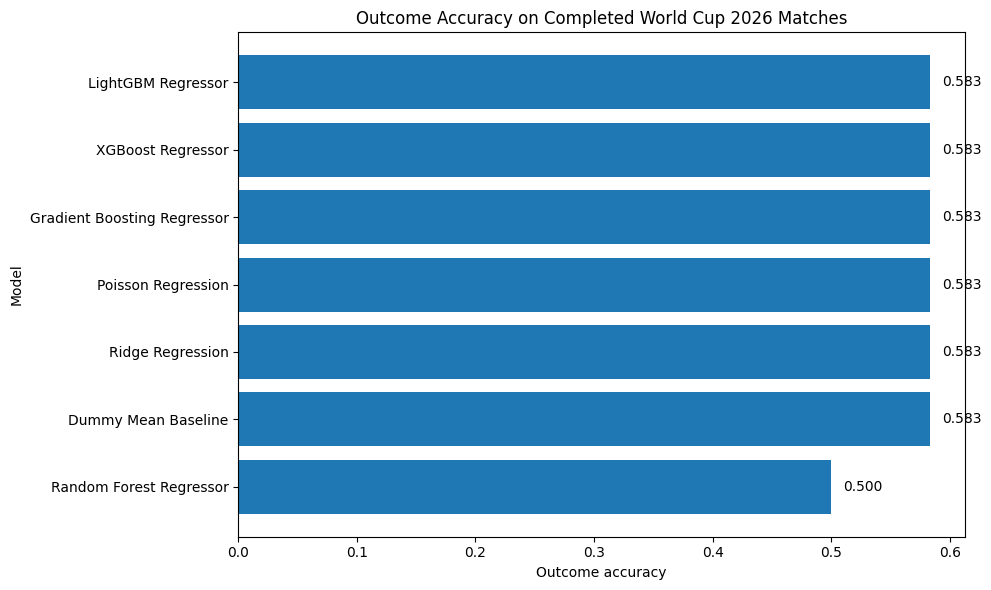

In [9]:
if model_validation_summary.empty:
    raise ValueError("model_validation_summary is empty. No chart can be plotted.")

plot_df = model_validation_summary.sort_values("outcome_accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["model"], plot_df["outcome_accuracy"])
ax.set_title("Outcome Accuracy on Completed World Cup 2026 Matches")
ax.set_xlabel("Outcome accuracy")
ax.set_ylabel("Model")

for i, value in enumerate(plot_df["outcome_accuracy"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_outcome_accuracy_completed_matches.png", dpi=150)
plt.show()


## Chart 2 — Exact Score Accuracy on Completed Matches

This chart shows how often the exact rounded score matched the actual final score.

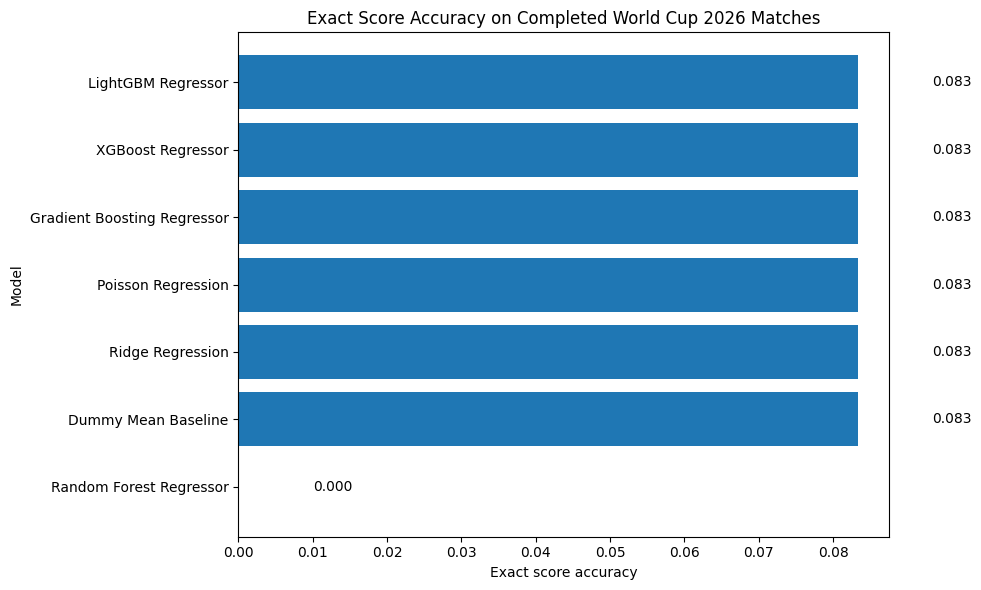

In [10]:
if model_validation_summary.empty:
    raise ValueError("model_validation_summary is empty. No chart can be plotted.")

plot_df = model_validation_summary.sort_values("exact_score_accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["model"], plot_df["exact_score_accuracy"])
ax.set_title("Exact Score Accuracy on Completed World Cup 2026 Matches")
ax.set_xlabel("Exact score accuracy")
ax.set_ylabel("Model")

for i, value in enumerate(plot_df["exact_score_accuracy"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_exact_score_accuracy_completed_matches.png", dpi=150)
plt.show()


## Chart 3 — Goal Error on Completed Matches

Lower error means the model predicted the scoreline closer to the actual result.

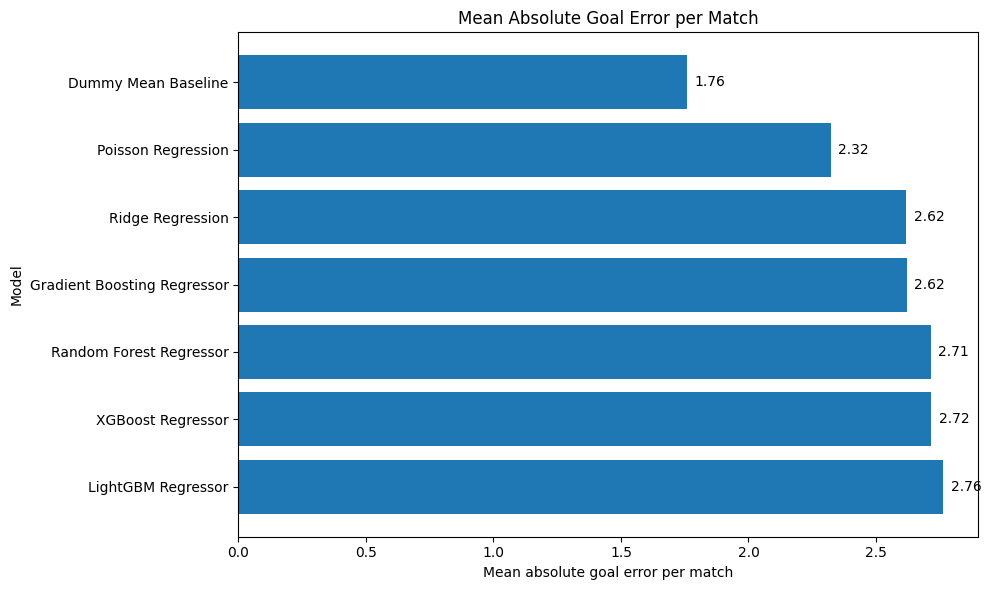

In [11]:
if model_validation_summary.empty:
    raise ValueError("model_validation_summary is empty. No chart can be plotted.")

plot_df = model_validation_summary.sort_values("mean_match_goal_error", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["model"], plot_df["mean_match_goal_error"])
ax.set_title("Mean Absolute Goal Error per Match")
ax.set_xlabel("Mean absolute goal error per match")
ax.set_ylabel("Model")

for i, value in enumerate(plot_df["mean_match_goal_error"]):
    ax.text(value + 0.03, i, f"{value:.2f}", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_mean_goal_error_completed_matches.png", dpi=150)
plt.show()


## Match-Level Best Model Table

For each completed match, this table shows which model had the smallest score error.

In [12]:
# Robust best model per completed match.
# Use completed_match_key instead of match_number, because match_number can be missing
# after team-name based matching.

if "completed_match_key" not in validation_df.columns:
    validation_df["completed_match_key"] = (
        validation_df["team_a"].astype(str).str.lower()
        + " vs "
        + validation_df["team_b"].astype(str).str.lower()
    )

best_per_match = (
    validation_df
    .sort_values(
        by=[
            "completed_match_key",
            "total_abs_goal_error",
            "outcome_correct",
            "exact_score_correct",
        ],
        ascending=[True, True, False, False]
    )
    .drop_duplicates(subset=["completed_match_key"], keep="first")
    .copy()
)

print("Completed matches in validation:", validation_df["completed_match_key"].nunique())
print("Rows in best_per_match:", len(best_per_match))

display(best_per_match[[
    "completed_match_key", "match_number", "group", "team_a", "team_b",
    "actual_score", "model", "predicted_score",
    "predicted_result", "actual_result",
    "outcome_correct", "exact_score_correct",
    "total_abs_goal_error",
]])

best_per_match.to_csv(TABLES_DIR / "best_model_per_completed_match.csv", index=False)
print("Saved:", TABLES_DIR / "best_model_per_completed_match.csv")


Completed matches in validation: 12
Rows in best_per_match: 12


,completed_match_key,match_number,group,team_a,team_b,actual_score,model,predicted_score,predicted_result,actual_result,outcome_correct,exact_score_correct,total_abs_goal_error
11,albania/poland/sweden/ukraine vs tunisia,<NA>,Group F,Albania/Poland/Sweden/Ukraine,Tunisia,5 - 1,Dummy Mean Baseline,2 - 1,team_a_win,team_a_win,True,False,3.331625
5,australia vs kosovo/romania/slovakia/türkiye,<NA>,Group D,Australia,Kosovo/Romania/Slovakia/Türkiye,2 - 0,Dummy Mean Baseline,2 - 1,team_a_win,team_a_win,True,False,1.117375
6,brazil vs morocco,<NA>,Group C,Brazil,Morocco,1 - 1,Dummy Mean Baseline,2 - 1,team_a_win,draw,False,False,0.882625
2,canada vs bosnia and herzegovina/italy/norther...,<NA>,Group B,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,1 - 1,Dummy Mean Baseline,2 - 1,team_a_win,draw,False,False,0.882625
68,côte d'ivoire vs ecuador,<NA>,Group E,Côte d'Ivoire,Ecuador,1 - 0,XGBoost Regressor,2 - 1,team_a_win,team_a_win,True,False,1.272080
21,germany vs curaçao,<NA>,Group E,Germany,Curaçao,7 - 1,Ridge Regression,2 - 1,team_a_win,team_a_win,True,False,4.931616
52,haiti vs scotland,<NA>,Group C,Haiti,Scotland,0 - 1,Gradient Boosting Regressor,2 - 1,team_a_win,team_b_win,False,False,1.877942
1,korea republic vs czechia/denmark/north macedo...,<NA>,Group A,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,2 - 1,Dummy Mean Baseline,2 - 1,team_a_win,team_a_win,True,True,0.331625
72,mexico vs south africa,<NA>,Group A,Mexico,South Africa,2 - 0,LightGBM Regressor,2 - 1,team_a_win,team_a_win,True,False,0.557105
82,netherlands vs japan,<NA>,Group F,Netherlands,Japan,2 - 2,LightGBM Regressor,2 - 1,team_a_win,draw,False,False,1.129658


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\actual_worldcup2026_validation\tables\best_model_per_completed_match.csv


## Chart 4 — Best Model Count per Match

This chart counts how often each model was closest to the real score among completed matches.

,model,count
0,Dummy Mean Baseline,6
1,Ridge Regression,2
2,LightGBM Regressor,2
3,XGBoost Regressor,1
4,Gradient Boosting Regressor,1


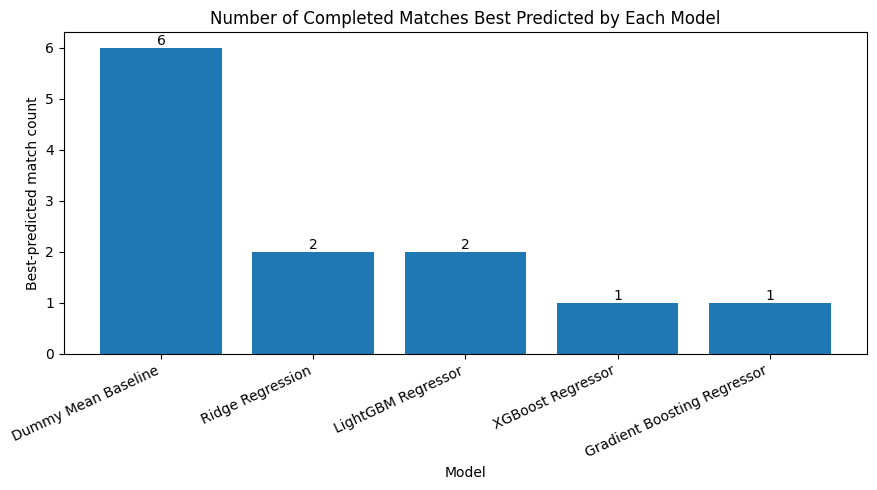

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\actual_worldcup2026_validation\figures\04_best_model_count_per_match.png


In [13]:
# Count how often each model was closest to the actual score.

best_model_counts = (
    best_per_match["model"]
    .value_counts()
    .reset_index()
)

best_model_counts.columns = ["model", "count"]

display(best_model_counts)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(best_model_counts["model"], best_model_counts["count"])
ax.set_title("Number of Completed Matches Best Predicted by Each Model")
ax.set_xlabel("Model")
ax.set_ylabel("Best-predicted match count")
plt.xticks(rotation=25, ha="right")

for i, value in enumerate(best_model_counts["count"]):
    ax.text(i, value + 0.05, str(value), ha="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_best_model_count_per_match.png", dpi=150)
plt.show()

print("Saved:", FIGURES_DIR / "04_best_model_count_per_match.png")


## Detailed Comparison Table for Presentation

This compact table is useful for presentation and interpretation.

In [14]:
presentation_table = validation_df[[
    "match_number", "group", "team_a", "team_b", "model",
    "actual_score", "predicted_score",
    "actual_result", "predicted_result",
    "outcome_correct", "exact_score_correct",
    "total_abs_goal_error",
]].copy()

presentation_table = presentation_table.sort_values(["match_number", "model"]).reset_index(drop=True)

display(presentation_table)

presentation_table.to_csv(TABLES_DIR / "presentation_actual_vs_model_predictions.csv", index=False)
print("Saved:", TABLES_DIR / "presentation_actual_vs_model_predictions.csv")


,match_number,group,team_a,team_b,model,actual_score,predicted_score,actual_result,predicted_result,outcome_correct,exact_score_correct,total_abs_goal_error
0,<NA>,Group A,Mexico,South Africa,Dummy Mean Baseline,2 - 0,2 - 1,team_a_win,team_a_win,True,False,1.117375
1,<NA>,Group A,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...,Dummy Mean Baseline,2 - 1,2 - 1,team_a_win,team_a_win,True,True,0.331625
2,<NA>,Group B,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...,Dummy Mean Baseline,1 - 1,2 - 1,draw,team_a_win,False,False,0.882625
3,<NA>,Group D,USA,Paraguay,Dummy Mean Baseline,4 - 1,2 - 1,team_a_win,team_a_win,True,False,2.331625
4,<NA>,Group C,Haiti,Scotland,Dummy Mean Baseline,0 - 1,2 - 1,team_b_win,team_a_win,False,False,1.882625
...,...,...,...,...,...,...,...,...,...,...,...,...
79,<NA>,Group B,Qatar,Switzerland,XGBoost Regressor,1 - 1,1 - 1,draw,draw,True,True,0.700786
80,<NA>,Group E,Côte d'Ivoire,Ecuador,XGBoost Regressor,1 - 0,2 - 1,team_a_win,team_a_win,True,False,1.272080
81,<NA>,Group E,Germany,Curaçao,XGBoost Regressor,7 - 1,2 - 1,team_a_win,team_a_win,True,False,5.344634
82,<NA>,Group F,Netherlands,Japan,XGBoost Regressor,2 - 2,2 - 1,draw,team_a_win,False,False,1.320165


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\actual_worldcup2026_validation\tables\presentation_actual_vs_model_predictions.csv


## Final Output Overview

The validation output folder contains tables and figures for comparing real World Cup 2026 results with model predictions.

In [15]:
print("Tables:")
print(" - output/actual_worldcup2026_validation/tables/actual_completed_worldcup2026_results.csv")
print(" - output/actual_worldcup2026_validation/tables/worldcup2026_fixture_predictions_all_regression_models.csv")
print(" - output/actual_worldcup2026_validation/tables/actual_vs_predicted_completed_matches_all_models.csv")
print(" - output/actual_worldcup2026_validation/tables/actual_validation_summary_by_model.csv")
print(" - output/actual_worldcup2026_validation/tables/best_model_per_completed_match.csv")
print(" - output/actual_worldcup2026_validation/tables/presentation_actual_vs_model_predictions.csv")

print("\nFigures:")
print(" - output/actual_worldcup2026_validation/figures/01_outcome_accuracy_completed_matches.png")
print(" - output/actual_worldcup2026_validation/figures/02_exact_score_accuracy_completed_matches.png")
print(" - output/actual_worldcup2026_validation/figures/03_mean_goal_error_completed_matches.png")
print(" - output/actual_worldcup2026_validation/figures/04_best_model_count_per_match.png")

print("\nActual World Cup 2026 validation completed.")


Tables:
 - output/actual_worldcup2026_validation/tables/actual_completed_worldcup2026_results.csv
 - output/actual_worldcup2026_validation/tables/worldcup2026_fixture_predictions_all_regression_models.csv
 - output/actual_worldcup2026_validation/tables/actual_vs_predicted_completed_matches_all_models.csv
 - output/actual_worldcup2026_validation/tables/actual_validation_summary_by_model.csv
 - output/actual_worldcup2026_validation/tables/best_model_per_completed_match.csv
 - output/actual_worldcup2026_validation/tables/presentation_actual_vs_model_predictions.csv

Figures:
 - output/actual_worldcup2026_validation/figures/01_outcome_accuracy_completed_matches.png
 - output/actual_worldcup2026_validation/figures/02_exact_score_accuracy_completed_matches.png
 - output/actual_worldcup2026_validation/figures/03_mean_goal_error_completed_matches.png
 - output/actual_worldcup2026_validation/figures/04_best_model_count_per_match.png

Actual World Cup 2026 validation completed.
